# From hyperspectral images to chemical maps
In this notebook we train a modified U-Net end to end to turn a near-infrared hyperspectral image of a pork belly slice into a pixel-wise map of fat content, using only one mean reference value per belly. The tutorial follows the study of Engstrøm et al. (2025) step by step: the data preparation, the compound Conv3D + U-Net model, the four-term loss function, the training pipeline and the analysis of the resulting chemical maps.

Based on the research of Ole-Christian Galbo Engstrøm (ocge@foss.dk) and co-authors<br>
Reference study: Engstrøm, Albano-Gaglio, Dreier, Bouzembrak, Font-i-Furnols, Mishra, Pedersen (2025). Transforming Hyperspectral Images Into Chemical Maps: A Novel End-to-End Deep Learning Approach. Journal of Chemometrics 39:e70041, https://doi.org/10.1002/cem.70041<br>

## The story of this notebook

In the previous lab every model ended with a single number per belly. The image models looked at pictures, but in the end they compressed everything into one prediction. Yet the reason to buy a hyperspectral camera instead of a spectrometer is that it can tell us where things are. A processing plant that knows where the fat sits in a belly can cut it more precisely and sell each part for what it is worth. What we want is a chemical map: an image in which every pixel holds a fat percentage.

The classical recipe is simple. Train a PLS model on mean spectra and reference values, then apply it to every pixel separately. The study we follow shows what goes wrong with that:

- The maps are dominated by noise. In the test set only 2.37% of the variance in PLS-generated maps was spatially correlated. Neighbouring pixels behave almost as if they were independent.
- The predictions leave the physically possible range. Pixel values from about -2000% to +2000% fat were observed, while the truth must lie between 0% and 100%.
- Each pixel is analysed in isolation, so the model cannot use the obvious fact that fat comes in layers and regions, not in random speckles.

The study proposes an end-to-end alternative. A U-Net, a convolutional network designed for pixel-wise tasks, receives the whole hyperspectral image and outputs the whole chemical map at once. The difficulty is supervision: nobody can measure the fat content of a single pixel, we only have the chemical reference of the whole minced belly. The solution is a loss function that tells the network what a good chemical map must look like:

1. Its mean over the meat pixels must match the reference value (mean squared error).
2. Every pixel must stay between 0% and 100% (out-of-bounds loss).
3. Neighbouring pixels should have similar values (smoothness loss).
4. The weights should stay small (L2 regularisation).

The result: a test RMSE on mean fat 7% lower than PLS, chemical maps in which 99.91% of the variance is spatially correlated, and pixel predictions that stay in the 0 to 100% range. Nobody told the network where the fat is, yet it learns spatial patterns (more fat at the back of the animal than at the belly side) that agree with independent firmness measurements.

Roadmap:

| Section | Topic |
|---|---|
| 3 | the dataset, the two-stage padding scheme, masks |
| 4 | the compound model: a 3D convolution front-end plus a modified U-Net |
| 5 | the four-term loss function, with toy examples |
| 6 | the training pipeline with burn-in, plateau schedule, weight restoring and early stopping |
| 7 | GPU CHECKPOINT: loading the ensemble of five pre-trained U-Nets |
| 8 | chemical maps, belly predictions and the spatial statistics of the maps |
| 9 | the classical pixel-wise PLS map, for contrast |

## 0) Setup for Google Colab

Two extra packages are needed: `ikpls` for the PLS baseline at the end.

In [28]:
## Install the packages that are missing in Google Colab
!pip install -q ikpls

### Getting the course data

The padded images that the U-Net was trained on take about 330 GB for the whole dataset. The course folder contains the images of two test bellies only, a lean one and a fat one (5 slices of about 355 MB each per belly), together with the metadata, the mean spectra and the weights of the five trained U-Nets.

The part of the folder used by this notebook:

```
end2end/
    red_data_with_splits.csv          one row per belly: meat_id, Fat_chem, split, ...
    meat_id_mean_spectra/absorbance/  {meat_id}.npy mean spectra (used for the PLS comparison)
    HSI_data_binned_spectra/          two example bellies, already padded
        images/        {meat_id}-{slice}.npy   uint16, (62, 2360, 1272)
        masks/         {meat_id}-{slice}.npy   float, (1, 996, 452), at the resolution of the U-Net output
        quant_biases/  {meat_id}-{slice}.npy   float32 scalar
        quant_scales/  {meat_id}-{slice}.npy   float32 scalar
    unet/
        1/best_weights.pt ... 5/best_weights.pt   the five U-Nets of the study (one per CV fold)
```

The U-Net weights were published by the authors on Hugging Face (`Sm00thix/unet_chemical_map`, licence CC BY-NC 4.0). 

In [29]:
from pathlib import Path

## Mount Google Drive when running in Colab (outside Colab this is simply skipped)
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

## ------------------------------------------------------------------------------
## USER SETTINGS
## ------------------------------------------------------------------------------
## The shortcut to the shared course folder in your Google Drive
SHARED_DATA = Path('/content/drive/MyDrive/data/end2end')
LOCAL_DATA = Path('data/end2end')

## Demonstration of the training step (section 6.3): number of optimizer steps, and the size of the
## piece of a slice that is used, given as the size of the U-Net input after the Conv3D front-end.
## Not every size is valid for this U-Net, see section 4.4; (428, 316) gives a 856 x 632 pixel crop.
DEMO_STEPS = 15
DEMO_UNET_HW = (428, 316)

## How many ensemble members and slices per belly to use for the chemical maps in section 8.
EVAL_MEMBERS_GPU, EVAL_SLICES_PER_BELLY_GPU = 5, None      # None = all slices
EVAL_MEMBERS_CPU, EVAL_SLICES_PER_BELLY_CPU = 2, 2

DATA_ROOT = SHARED_DATA if IN_COLAB else LOCAL_DATA

CSV_PATH = DATA_ROOT / 'red_data_with_splits.csv'
UNET_DATA = DATA_ROOT / 'HSI_data_binned_spectra'
SPECTRA_PATH = DATA_ROOT / 'meat_id_mean_spectra' / 'absorbance'
PRETRAINED_DIR = DATA_ROOT / 'unet'
for p in [CSV_PATH, UNET_DATA, SPECTRA_PATH, PRETRAINED_DIR]:
    print(f"{'found  ' if p.exists() else 'MISSING'}  {p}")

found    data/end2end/red_data_with_splits.csv
found    data/end2end/HSI_data_binned_spectra
found    data/end2end/meat_id_mean_spectra/absorbance
found    data/end2end/unet


## 1) Import packages

In [30]:
import os
import sys
import math
import time
import random
import shutil
import platform
import gc
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from IPython.display import display
from scipy.signal import savgol_coeffs, savgol_filter

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.v2 as T
from torchvision import tv_tensors
from tqdm.auto import tqdm

For future reference, we list the versions of the main packages and the hardware.

In [31]:
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

print('\n--------  Running on', platform.node(), 'using', platform.platform(), '--------\n')
print('Last run at =', datetime.now().strftime('%d/%m/%Y %H:%M:%S'))
print('\n-------- SOFTWARE INFO --------')
print('Python     ', sys.version.split()[0])
print('PyTorch    ', torch.__version__)
print('NumPy      ', np.__version__)
print('Pandas     ', pd.__version__)
print('\n-------- HARDWARE INFO --------')
print('CPU cores:', os.cpu_count())
try:
    import psutil
    print(f'RAM: {psutil.virtual_memory().total / 1024**3:.1f} GB')
except ImportError:
    pass
if DEVICE == 'cuda':
    props = torch.cuda.get_device_properties(0)
    print(f'GPU: {props.name}, {props.total_memory / 1024**3:.1f} GB memory')
else:
    print('GPU: none, running on the CPU')
print('\nDEVICE =', DEVICE)


--------  Running on L0164910 using Linux-5.15.146.1-microsoft-standard-WSL2-x86_64-with-glibc2.35 --------

Last run at = 03/10/2026 10:53:29

-------- SOFTWARE INFO --------
Python      3.11.13
PyTorch     2.5.1+cu121
NumPy       2.4.6
Pandas      2.3.0

-------- HARDWARE INFO --------
CPU cores: 24
RAM: 15.5 GB
GPU: NVIDIA RTX A5500 Laptop GPU, 16.0 GB memory

DEVICE = cuda


## 2) Help functions

Seeding for reproducibility, the two regression metrics, a function that renders a false-colour image from three bands of a hyperspectral cube, and the shape tracer from notebook 1.

In [32]:
def reproducible_comp(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def rmse(pred, true):
    pred, true = np.asarray(pred, float).ravel(), np.asarray(true, float).ravel()
    return float(np.sqrt(np.mean((pred - true) ** 2)))


def r2_score(pred, true):
    pred, true = np.asarray(pred, float).ravel(), np.asarray(true, float).ravel()
    return float(1 - np.sum((true - pred) ** 2) / np.sum((true - true.mean()) ** 2))


def false_colour(cube, bands=(55, 30, 5)):
    '''Map three bands of a (C, H, W) cube to RGB with a robust 2 to 98 percentile stretch.'''
    rgb = np.stack([np.asarray(cube[b], dtype=np.float64) for b in bands], axis=-1)
    lo, hi = np.percentile(rgb, 2, axis=(0, 1)), np.percentile(rgb, 98, axis=(0, 1))
    return np.clip((rgb - lo) / (hi - lo + 1e-12), 0, 1)


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


reproducible_comp()
plt.rc('font', size=10)
plt.rc('axes', titlesize=10, labelsize=12)

## 3) The data

### 3.1) The dataset in numbers

The dataset (Albano-Gaglio et al., 2025) contains 182 pork bellies from pigs of five fat classes. Each belly was cut into five slices (nine slices are missing, so there are 901), and each slice was imaged with a VIS-NIR camera with 300 wavelength channels from 386.63 nm to 1015.78 nm. The chemical fat content of each whole belly was measured in the lab.

The split column of the CSV defines six subsets, created with a modified DUPLEX algorithm so that each subset spans the variation of the data:

- split 0 is the test set (60 bellies, 298 slices);
- splits 1 to 5 are the five folds of the cross-validation (CV) set (122 bellies).

In the study one U-Net was trained per CV fold: fold $k$ was the validation set and the other four folds were the training set. The five resulting networks form an ensemble whose prediction is the average of its members. The table counts the bellies in the CSV and the slices available in the course folder: the full dataset in the CSV, two example bellies on disk.

In [33]:
REFERENCE_VALUES = ['Fat_chem']
TEST_SETS = [0]
CV_SETS = [1, 2, 3, 4, 5]

meta = pd.read_csv(CSV_PATH)
slice_files = sorted((UNET_DATA / 'images').glob('*.npy'))
slices = pd.DataFrame({'stem': [f.stem for f in slice_files]})
slices['meat_id'] = slices.stem.str.split('-').str[0].astype(int)
slices = slices.merge(meta[['meat_id', 'split', 'Fat_chem']], on='meat_id')

table = pd.DataFrame({
    'bellies (CSV)': meta.groupby('split').size(),
    'bellies with slices on disk': slices.groupby('split').meat_id.nunique(),
    'slices on disk': slices.groupby('split').size(),
}).fillna(0).astype(int)
table.index = [f'split {i}' + (' (test)' if i in TEST_SETS else '') for i in table.index]
display(table)

,bellies (CSV),bellies with slices on disk,slices on disk
split 0 (test),60,2,10
split 1,25,0,0
split 2,25,0,0
split 3,24,0,0
split 4,24,0,0
split 5,24,0,0


### 3.2) What happened to the images before they reached us

The files in `HSI_data_binned_spectra` are the end product of several preprocessing steps described in the paper. Each step solves a concrete problem:

1. Band selection and binning. Only the 124 channels above 747.92 nm are kept (chemistry, not colour), and neighbouring channels are averaged in pairs, giving 62 bands. Fewer bands means less memory and helps against the curse of dimensionality.
2. Quantisation. Reflectance is stored as `uint16` with a per-slice bias and scale, $R = q/\mathrm{scale} + \mathrm{bias}$.
3. Two-stage padding to 2360 x 1272 pixels. The U-Net uses only valid convolutions (no zero padding inside the network), so its output is smaller than its input. With the chosen sizes the output covers the central 1992 x 904 pixels of the input (at half resolution, see section 4). The padding is therefore done in two stages:
    - stage 1 pads every image with a background spectrum up to 1992 x 904. The background spectrum is the average of the left-most and right-most image columns, which are almost pure background;
    - stage 2 mirror-pads to 2360 x 1272, so that the network has realistic context around the region it predicts, just like in the original U-Net paper.
4. Masks. The original segmentation mask (fat tissue versus background) was padded the same way, cropped to the central 1992 x 904 pixels, halved to 996 x 452 with bilinear interpolation and rounding, and finally eroded by a disk of radius one pixel. The erosion guarantees that every mask pixel has meat neighbours to the right and below, so spatial differences inside the mask are always computed between meat pixels (this matters for the smoothness loss in section 5).

The cell below illustrates the two-stage padding on a small artificial cube, using a background padding function followed by mirror padding.

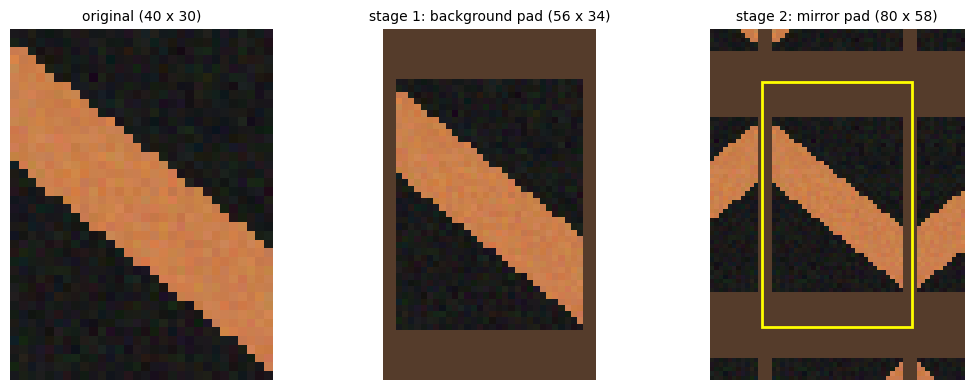

In [34]:
def pad_with_average_spectrum(img, out_h, out_w):
    '''Stage 1: pad a (H, W, C) image to (out_h, out_w) with the mean spectrum of its outer columns.'''
    h, w, c = img.shape
    bg = (img[:, 0, :].mean(axis=0) + img[:, -1, :].mean(axis=0)) / 2
    out = np.tile(bg, (max(out_h, h), max(out_w, w), 1)).astype(img.dtype)
    top, left = (out.shape[0] - h) // 2, (out.shape[1] - w) // 2
    out[top:top + h, left:left + w] = img
    return out


def two_stage_pad(img, stage1_hw, final_hw):
    stage1 = pad_with_average_spectrum(img, *stage1_hw)
    ph, pw = final_hw[0] - stage1.shape[0], final_hw[1] - stage1.shape[1]
    t = torch.from_numpy(np.moveaxis(stage1, -1, 0))[None]          # (1, C, H, W)
    t = F.pad(t, (pw // 2, pw - pw // 2, ph // 2, ph - ph // 2), mode='reflect')   # stage 2: mirror
    return stage1, np.moveaxis(t[0].numpy(), 0, -1)


## A toy 'slice': background plus a bright tilted band of 'meat', 40 x 30 pixels, 3 bands
yy, xx = np.mgrid[0:40, 0:30]
toy = np.full((40, 30, 3), 0.1)
meat = np.abs(yy - 0.8 * xx - 8) < 7
toy[meat] = [0.8, 0.5, 0.3]
toy += np.random.default_rng(0).normal(0, 0.02, toy.shape)

stage1, final = two_stage_pad(toy, stage1_hw=(56, 34), final_hw=(80, 58))
fig, axes = plt.subplots(1, 3, figsize=(11, 4))
for ax, im, title in zip(axes, [toy, stage1, final], ['original (40 x 30)', 'stage 1: background pad (56 x 34)', 'stage 2: mirror pad (80 x 58)']):
    ax.imshow(np.clip(im, 0, 1))
    ax.set_title(title)
    ax.axis('off')
axes[2].add_patch(patches.Rectangle(((58 - 34) / 2 - 0.5, (80 - 56) / 2 - 0.5), 34, 56, fill=False, ec='yellow', lw=2))
plt.tight_layout()
plt.show()

The yellow box marks the region for which the network will produce predictions. Everything outside it is context only. Now let us look at a real padded slice and its mask.

slice 10-1: image (62, 2360, 1272) float32, mask (1, 996, 452), reflectance in [0.000, 2.013]


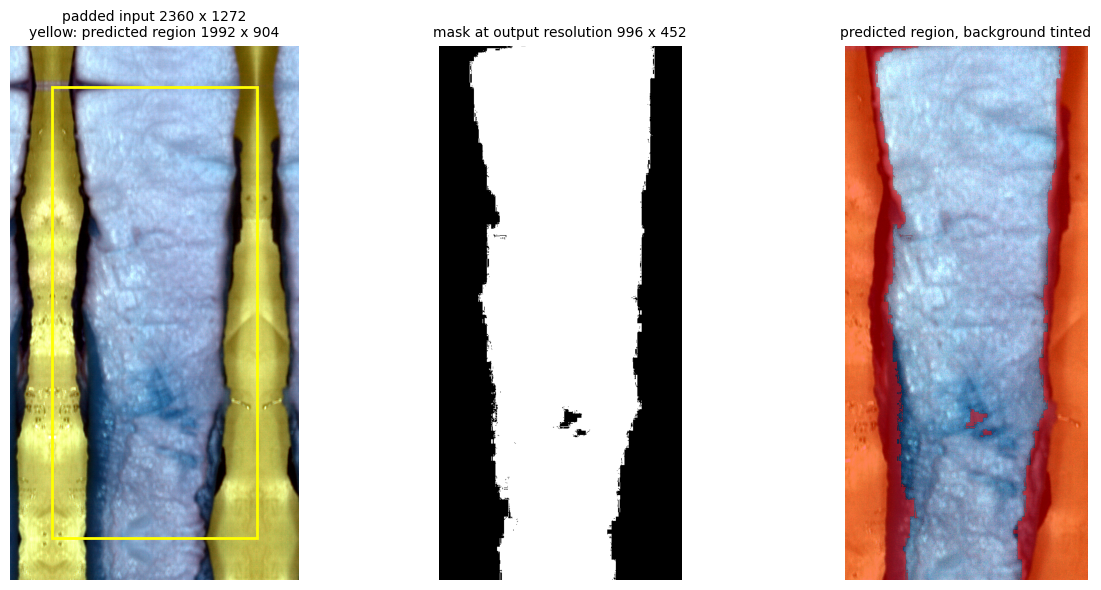

In [35]:
def dequantize_16_bit(arr, bias, scale):
    return (arr / scale) + bias


def load_slice(stem, base=UNET_DATA):
    q = np.load(base / 'images' / f'{stem}.npy')
    bias = np.load(base / 'quant_biases' / f'{stem}.npy')
    scale = np.load(base / 'quant_scales' / f'{stem}.npy')
    mask = np.load(base / 'masks' / f'{stem}.npy').astype(np.float32)
    return dequantize_16_bit(q, bias, scale).astype(np.float32), mask


example_stem = slices[slices.split.isin(TEST_SETS)].stem.iloc[0] if (slices.split == 0).any() else slices.stem.iloc[0]
img, mask = load_slice(example_stem)
IN_H, IN_W = img.shape[-2:]
OUT_H, OUT_W = mask.shape[-2:]
print(f'slice {example_stem}: image {img.shape} {img.dtype}, mask {mask.shape}, reflectance in [{img.min():.3f}, {img.max():.3f}]')

## The predicted region: the central (2 * OUT_H) x (2 * OUT_W) input pixels (the output has half resolution)
reg_h, reg_w = 2 * OUT_H, 2 * OUT_W
top, left = (IN_H - reg_h) // 2, (IN_W - reg_w) // 2

fig, axes = plt.subplots(1, 3, figsize=(13, 6))
axes[0].imshow(false_colour(img))
axes[0].add_patch(patches.Rectangle((left, top), reg_w, reg_h, fill=False, ec='yellow', lw=2))
axes[0].set_title(f'padded input {IN_H} x {IN_W}\nyellow: predicted region {reg_h} x {reg_w}')
axes[1].imshow(mask[0], cmap='gray', vmin=0, vmax=1)
axes[1].set_title(f'mask at output resolution {OUT_H} x {OUT_W}')
crop = false_colour(img[:, top:top + reg_h, left:left + reg_w])[::2, ::2]
axes[2].imshow(crop)
axes[2].imshow(np.ma.masked_where(mask[0] > 0, mask[0]), cmap='autumn', alpha=0.5)
axes[2].set_title('predicted region, background tinted')
for a in axes:
    a.axis('off')
plt.tight_layout()
plt.show()

### 3.3) Dataset, flips and DataLoader

In the `Dataset` below, one item is one slice, and the target of every slice is the reference value of its belly. This is a deliberate approximation: the five slices of a belly do not have exactly the same fat content, but we have no better information. The model is asked to produce a map whose mean inside the mask equals the belly value.

Two details are worth pointing out:

- The image is dequantised in the dataset and given to the network as reflectance, not absorbance. The learnable 3D front-end can learn whatever transformation of the spectra it needs.
- Augmentation flips the image and the mask together, horizontally and vertically, each with probability 0.5. The torchvision `v2` transforms make this easy: when an `Image` and a `Mask` are passed together, the same random decision is applied to both. The image and the mask have different sizes, but because the padding is symmetric, the predicted region stays exactly centred and a flip of both keeps them aligned.

The target is returned together with the mask as one tuple `(mask, reference)`, because the loss function needs both.

In [36]:
def get_random_flip_transform():
    return T.Compose([T.RandomHorizontalFlip(p=0.5), T.RandomVerticalFlip(p=0.5)])


class PreprocessedImageDataset(Dataset):
    '''One item per slice: (image (62, H, W) float reflectance, (mask (1, h, w), reference (1,)), file_id).'''

    def __init__(self, base, splits, transform=None, stems=None):
        self.base = Path(base)
        self.df = meta[meta['split'].isin(splits)].set_index('meat_id')
        self.transform = transform
        files = sorted((self.base / 'images').glob('*.npy'))
        self.stems = [f.stem for f in files if int(f.stem.split('-')[0]) in self.df.index]
        if stems is not None:                      # optional restriction to a list of slices
            self.stems = [s for s in self.stems if s in set(stems)]

    def __len__(self):
        return len(self.stems)

    def __getitem__(self, idx):
        stem = self.stems[idx]
        meat_id = int(stem.split('-')[0])
        img, mask = load_slice(stem, self.base)
        img, mask = tv_tensors.Image(torch.from_numpy(img)), tv_tensors.Mask(torch.from_numpy(mask))
        if self.transform is not None:
            img, mask = self.transform(img, mask)
        refs = torch.tensor(self.df.loc[meat_id, REFERENCE_VALUES].values.astype(np.float32))
        return img.as_subclass(torch.Tensor), (mask.as_subclass(torch.Tensor), refs), stem


ds = PreprocessedImageDataset(UNET_DATA, TEST_SETS + CV_SETS)
x, (m, y), stem = ds[0]
print('number of slices:', len(ds))
print('image:', tuple(x.shape), x.dtype, '| mask:', tuple(m.shape), '| reference:', y.tolist(), '| id:', stem)

number of slices: 10
image: (62, 2360, 1272) torch.float32 | mask: (1, 996, 452) | reference: [25.479999542236328] | id: 10-1


## 4) The model: a 3D convolution front-end and a modified U-Net

The complete model is a `CompoundModel`, a chain of two models:

`input (B, 62, 2360, 1272)` -> `Conv3Don2D` -> `(B, 56, 1180, 636)` -> `U-Net` -> `(B, 1, 996, 452)` chemical map

### 4.1) The spectral front-end: a learnable Savitzky-Golay filter

The first layer is a 3D convolution with a single filter of size (depth, height, width) = (7, 2, 2). To apply a 3D convolution to a 2D image with 62 channels, the image is reshaped so that the bands become the depth axis of a one-channel volume:

$$(B, 62, H, W) \rightarrow (B, 1, 62, H, W) \xrightarrow{\text{Conv3d}} (B, 1, 56, H/2, W/2) \rightarrow (B, 56, H/2, W/2)$$

- Along the spectral axis the kernel has length 7 with stride 1 and no padding: 62 - 7 + 1 = 56 output bands. The same seven weights slide along the spectrum, exactly like a Savitzky-Golay filter with a window of seven. The PLS baseline of the study used a Savitzky-Golay second derivative with window 7, so the network can, in principle, learn exactly that preprocessing, or something better.
- Along the spatial axes the kernel is 2 x 2 with stride 2, so the image is halved in each direction. This makes training much cheaper and reduces the size of the output.

So the whole front-end has 7 x 2 x 2 = 28 weights plus one bias. A tiny layer, but one that encodes chemometric knowledge into the architecture.

In [37]:
class Permute(nn.Module):
    def __init__(self, dims):
        super().__init__()
        self.dims = dims

    def forward(self, x):
        return x.permute(self.dims)


class Conv3Don2D(nn.Module):
    '''3D convolution on a (B, C, H, W) image, treating the C bands as depth.'''

    def __init__(self, in_channels, num_filters, kernel_size, normalization):
        super().__init__()
        bias = normalization is None
        self.conv = nn.Conv3d(in_channels=1, out_channels=num_filters, kernel_size=kernel_size,
                              stride=(1, 2, 2), padding='valid', bias=bias)
        self.num_filters = num_filters
        self.normalization = normalization
        if normalization == 'bn':
            self.norm_layer = nn.BatchNorm3d(num_filters, momentum=0.01)
        elif normalization == 'ln':
            self.norm_layer = nn.Sequential(Permute((0, 2, 3, 4, 1)), nn.LayerNorm(num_filters), Permute((0, 4, 1, 2, 3)))
        else:
            self.norm_layer = nn.Identity()
        self.out_channels = num_filters * (in_channels - kernel_size[0] + 1)
        nn.init.kaiming_normal_(self.conv.weight)      # Kaiming He normal weights, zero bias
        if self.conv.bias is not None:
            nn.init.constant_(self.conv.bias, 0)

    def forward(self, x):
        x = x.view(-1, 1, x.size(-3), x.size(-2), x.size(-1))           # (B, 1, C, H, W)
        x = self.norm_layer(self.conv(x))                               # (B, F, C - k + 1, H / 2, W / 2)
        return x.view(-1, self.out_channels, x.size(-2), x.size(-1))     # (B, F * (C - k + 1), H / 2, W / 2)


class CompoundModel(nn.Module):
    '''Apply several models one after the other.'''

    def __init__(self, *models):
        super().__init__()
        self.models = nn.ModuleList(models)

    def forward(self, x):
        for model in self.models:
            x = model(x)
        return x

Let us prove the claim about Savitzky-Golay. We set the 28 weights of the front-end by hand: along the bands, the coefficients of a Savitzky-Golay second derivative filter (window 7, polynomial order 2); spatially, a plain 2 x 2 average (each weight 1/4). Then we compare its output with the classical route: average 2 x 2 pixel blocks and apply `scipy.signal.savgol_filter` to every pixel spectrum. Both should agree to numerical precision on the bands where the filter window fits completely.

In [38]:
sg = savgol_coeffs(7, polyorder=2, deriv=2, use='dot')          # the 7 Savitzky-Golay coefficients
print('Savitzky-Golay 2nd derivative coefficients:', np.round(sg, 4))

front = Conv3Don2D(in_channels=62, num_filters=1, kernel_size=(7, 2, 2), normalization=None)
with torch.no_grad():
    w = torch.tensor(sg, dtype=torch.float32)[:, None, None] * torch.full((1, 2, 2), 0.25)   # (7, 2, 2)
    front.conv.weight.copy_(w[None, None])
    front.conv.bias.zero_()

ch, cw = IN_H // 2 - 32, IN_W // 2 - 32
patch = torch.from_numpy(img[:, ch:ch + 64, cw:cw + 64].copy())[None]   # a 64 x 64 pixel piece from the centre of the slice
with torch.no_grad():
    out_conv = front(patch)[0].numpy()                               # (56, 32, 32)

binned = patch[0].reshape(62, 32, 2, 32, 2).mean(axis=(2, 4)).numpy()  # 2 x 2 average pooling
out_sg = savgol_filter(binned, window_length=7, polyorder=2, deriv=2, axis=0)[3:-3]   # valid bands only
print('output shape of the front-end:', out_conv.shape)
print('max absolute difference with savgol_filter:', float(np.abs(out_conv - out_sg).max()))

Savitzky-Golay 2nd derivative coefficients: [ 0.119  -0.     -0.0714 -0.0952 -0.0714 -0.      0.119 ]
output shape of the front-end: (56, 32, 32)
max absolute difference with savgol_filter: 5.494803190231323e-08


During training the weights start from random values and are free to move anywhere. The network decides which spectral transformation serves the chemical map best.

### 4.2) The U-Net

The U-Net (Ronneberger et al., 2015) was designed for medical image segmentation, a pixel-wise classification task. Chemical mapping is the regression version of the same problem: a value for every pixel instead of a class. Its shape gives it its name:

- The contracting path (left side of the U) repeatedly applies two 3 x 3 convolutions with ReLU and a 2 x 2 max pooling. Each level halves the resolution and doubles the number of channels: 64, 128, 256, 512, 1024. Deep levels see a large region of the image with little spatial detail: they understand context ("this is the back side of the belly").
- The expanding path (right side) upsamples back to high resolution. At every level the upsampled features are concatenated with the features of the same level from the contracting path (the skip connections, the horizontal grey arrows in the original paper). This brings back the fine spatial detail that was lost by pooling.
- A final 1 x 1 convolution maps the 64 feature channels at every pixel to one output: the fat percentage.

The study modified the original U-Net in one way besides adding the front-end: upsampling uses bilinear interpolation followed by a 1 x 1 convolution, instead of a learned transposed convolution. Transposed convolutions are known to create checkerboard artifacts, square patterns that would be very visible in a smooth chemical map, and bilinear upsampling has fewer parameters.

As in the original U-Net, all convolutions are valid (no padding), so each 3 x 3 convolution trims one pixel from every border. That is why the skip connection has to crop the larger feature map from the contracting path to the size of the upsampled one (`copy_and_crop`), and why the output is smaller than the input.

The comments in the code below refer to the arrows in the U-Net figure of the original U-Net paper.

In [39]:
def conv3x3(in_channels, out_channels, bias, pad):
    return nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1 if pad else 'valid', bias=bias)


def get_norm_layer(normalization, in_channels):
    if normalization == 'bn':
        return nn.BatchNorm2d(in_channels, momentum=0.01)
    if normalization == 'ln':
        return nn.Sequential(Permute((0, 2, 3, 1)), nn.LayerNorm(in_channels), Permute((0, 3, 1, 2)))
    return nn.Identity()


def conv_block(in_channels, out_channels, non_linearity, normalization, bias, pad):
    '''Two 3x3 convolutions, each followed by the non-linearity and (optionally) a norm (two blue arrows).'''
    layers = []
    for _ in range(2):
        layers.append(conv3x3(in_channels, out_channels, bias=bias, pad=pad))
        layers.append(non_linearity)
        layers.append(get_norm_layer(normalization, out_channels))
        in_channels = out_channels
    return nn.Sequential(*layers)


def copy_and_crop(large, small):
    '''Crop the centre of 'large' to the size of 'small' and concatenate along channels (grey arrow).'''
    lh, lw = large.shape[-2:]
    sh, sw = small.shape[-2:]
    sx, sy = (lh - sh) // 2, (lw - sw) // 2
    return torch.cat([large[..., sx:sx + sh, sy:sy + sw], small], dim=-3)


class ContractionBlock(nn.Module):
    '''2x2 max pooling (red arrow) followed by a conv block (two blue arrows).'''

    def __init__(self, in_channels, out_channels, non_linearity, nonormalization, bias, pad):
        super().__init__()
        self.max_pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv_block = conv_block(in_channels, out_channels, non_linearity, nonormalization, bias, pad)

    def forward(self, x):
        return self.conv_block(self.max_pool(x))


class Upsample(nn.Module):
    '''Bilinear x2 upsampling + 1x1 convolution (modified U-Net), or a 2x2 transposed convolution (as in the original U-Net).'''

    def __init__(self, in_channels, out_channels, non_linearity, normalization, bias, bilinear):
        super().__init__()
        self.in_channels, self.out_channels = in_channels, out_channels
        self.non_linearity, self.normalization = non_linearity, normalization
        self.bias, self.bilinear = bias, bilinear
        if bilinear:
            layers = [nn.Upsample(mode='bilinear', scale_factor=2, align_corners=True),
                      nn.Conv2d(in_channels, out_channels, kernel_size=1), non_linearity]
        else:
            layers = [nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2, bias=bias), non_linearity]
        layers.append(get_norm_layer(normalization, out_channels))
        self.up = nn.Sequential(*layers)

    def forward(self, x):
        return self.up(x)


class ExpansionBlock(nn.Module):
    '''Upsample (green arrow), copy and crop (grey arrow), conv block (two blue arrows).'''

    def __init__(self, in_channels, out_channels, non_linearity, normalization, bias, bilinear, pad):
        super().__init__()
        self.pad = pad
        self.upsample = Upsample(in_channels, out_channels, non_linearity, normalization, bias, bilinear)
        self.conv_block = conv_block(in_channels, out_channels, non_linearity, normalization, bias, pad)

    def forward(self, large, small):
        x = self.upsample(small)
        if self.pad:   # only with padded convolutions: grow x to the size of the skip connection
            dh, dw = large.shape[-2] - x.shape[-2], large.shape[-1] - x.shape[-1]
            x = F.pad(x, (dw // 2, dw - dw // 2, dh // 2, dh - dh // 2))
        x = copy_and_crop(large, x)
        return self.conv_block(x)


class UNet(nn.Module):
    def __init__(self, in_channels, out_channels, pad, bilinear, normalization):
        super().__init__()
        self.in_channels, self.out_channels = in_channels, out_channels
        self.pad, self.bilinear, self.normalization = pad, bilinear, normalization
        self.bias_conv = normalization is None
        self.non_linearity = nn.ReLU(inplace=True)
        self.intermediate_channels = [64 * 2 ** i for i in range(5)]     # 64, 128, 256, 512, 1024
        ch = self.intermediate_channels
        self.first_convs = conv_block(in_channels, ch[0], self.non_linearity, normalization, self.bias_conv, pad)
        self.last_conv = nn.Conv2d(ch[0], out_channels, kernel_size=1)
        self.contraction1 = self._get_contraction_block(ch[0], ch[1])
        self.contraction2 = self._get_contraction_block(ch[1], ch[2])
        self.contraction3 = self._get_contraction_block(ch[2], ch[3])
        self.contraction4 = self._get_contraction_block(ch[3], ch[4])
        self.expansion4 = self._get_expansion_block(ch[4], ch[3])
        self.expansion3 = self._get_expansion_block(ch[3], ch[2])
        self.expansion2 = self._get_expansion_block(ch[2], ch[1])
        self.expansion1 = self._get_expansion_block(ch[1], ch[0])
        ## Kaiming He normal initialisation, zero biases
        for m in self.modules():
            if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
                nn.init.kaiming_normal_(m.weight)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, (nn.BatchNorm2d, nn.LayerNorm)):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def _get_contraction_block(self, i, o):
        return ContractionBlock(i, o, self.non_linearity, self.normalization, self.bias_conv, self.pad)

    def _get_expansion_block(self, i, o):
        return ExpansionBlock(i, o, self.non_linearity, self.normalization, self.bias_conv, self.bilinear, self.pad)

    def forward(self, x):
        x1 = self.first_convs(x)        # level 1:   64 channels
        x2 = self.contraction1(x1)      # level 2:  128 channels, 1/2 resolution
        x3 = self.contraction2(x2)      # level 3:  256 channels, 1/4
        x4 = self.contraction3(x3)      # level 4:  512 channels, 1/8
        x5 = self.contraction4(x4)      # bottom:  1024 channels, 1/16
        x = self.expansion4(x4, x5)     # back up, using the skip connections x4 ... x1
        x = self.expansion3(x3, x)
        x = self.expansion2(x2, x)
        x = self.expansion1(x1, x)
        return self.last_conv(x)        # one value per pixel

### 4.3) Assembling the compound model

The hyperparameters below are those of the study: 62 input bands, one 3D filter of size (7, 2, 2), so the U-Net receives (62 - 6) x 1 = 56 channels; no padding, bilinear upsampling, no normalisation layers, one output channel.

In [40]:
INPUT_CHANNELS = 124 // 2
OUT_CHANNELS = 1
CONV3D_FILTERS = 1
CONV3D_KERNEL = (7, 2, 2)
UNET_INPUT_CHANNELS = (INPUT_CHANNELS - (CONV3D_KERNEL[0] - 1)) * CONV3D_FILTERS


def build_model():
    compression_model = Conv3Don2D(INPUT_CHANNELS, CONV3D_FILTERS, CONV3D_KERNEL, normalization=None)
    unet = UNet(UNET_INPUT_CHANNELS, OUT_CHANNELS, pad=False, bilinear=True, normalization=None)
    return CompoundModel(compression_model, unet)


model = build_model()
print(f'U-Net input channels: {UNET_INPUT_CHANNELS}')
print(f'parameters of the 3D front-end: {count_parameters(model.models[0]):,}')
print(f'parameters of the U-Net       : {count_parameters(model.models[1]):,}')

U-Net input channels: 56
parameters of the 3D front-end: 29
parameters of the U-Net       : 28,973,313


### 4.4) Why 2360 x 1272? Size arithmetic of a valid-convolution U-Net

With valid convolutions and pooling, not every input size works. Every 3 x 3 convolution removes 2 pixels, every pooling halves the size (and must not drop an odd row), every upsampling doubles it. The function below follows a size through the network. For the input used in the study, every level comes out even, nothing is dropped, and the output is exactly 996 x 452. 

We then check the arithmetic with a real forward pass on PyTorch's `meta` device. A meta tensor has a shape but no data, so the pass costs neither memory nor time: a neat trick to inspect large networks.

In [41]:
def unet_size_table(size_in):
    rows = []
    s = (size_in - 2) // 2 + 1                    # Conv3D front-end: kernel 2, stride 2
    rows.append(('Conv3D front-end', s))
    s -= 4; rows.append(('first_convs', s)); skips = [s]
    for lvl in range(1, 5):
        assert s % 2 == 0, f'odd size {s} before pooling at level {lvl}: a row would be dropped'
        s = s // 2 - 4; rows.append((f'contraction{lvl}', s)); skips.append(s)
    for lvl in range(4, 0, -1):
        s = s * 2 - 4; rows.append((f'expansion{lvl}', s))
    return rows


def size_table(h, w):
    rh, rw = unet_size_table(h), unet_size_table(w)
    return pd.DataFrame({'stage': [r[0] for r in rh], 'height': [r[1] for r in rh], 'width': [r[1] for r in rw]})


print(f'Input {IN_H} x {IN_W}')
display(size_table(IN_H, IN_W))

meta_model = build_model().to('meta')
out_meta = meta_model(torch.empty(1, INPUT_CHANNELS, IN_H, IN_W, device='meta'))
print('meta forward pass output shape:', tuple(out_meta.shape), '| mask shape on disk:', mask.shape)
assert tuple(out_meta.shape[-2:]) == tuple(mask.shape[-2:]), 'model output and mask sizes do not match'
print(f'Border lost on each side, in output pixels: {(IN_H // 2 - OUT_H) // 2} (height), {(IN_W // 2 - OUT_W) // 2} (width)')

Input 2360 x 1272


,stage,height,width
0,Conv3D front-end,1180,636
1,first_convs,1176,632
2,contraction1,584,312
3,contraction2,288,152
4,contraction3,140,72
5,contraction4,66,32
6,expansion4,128,60
7,expansion3,252,116
8,expansion2,500,228
9,expansion1,996,452


meta forward pass output shape: (1, 1, 996, 452) | mask shape on disk: (1, 996, 452)
Border lost on each side, in output pixels: 92 (height), 92 (width)


92 output pixels (184 input pixels) are lost on every side. That number is no accident: it is the width of the mirror padding, (2360 - 1992) / 2 = 184. The padding scheme of section 3.2 and the architecture were designed together.

### 4.5) The ensemble

Each CV fold produces one U-Net. Since the fold-specific stopping epochs and learning-rate schedules cannot be meaningfully averaged into one retraining recipe, the study combines the five networks into an ensemble whose prediction is the uniform average of its members. Every slice of the CV set has then been used both for training (in four members) and for validation (in one member).

In [42]:
class EnsembleModel(nn.Module):
    '''Average the outputs of several models.'''

    def __init__(self, *models):
        super().__init__()
        self.models = nn.ModuleList(models)

    def forward(self, x):
        return torch.stack([model(x) for model in self.models]).mean(dim=0)

## 5) The loss function

This is the heart of the method. Let $\hat{Y} \in \mathbb{R}^{B \times H \times W}$ be the predicted chemical maps of a batch, $\mathbf{y} \in \mathbb{R}^B$ the belly reference values and $M \in \{0, 1\}^{B \times H \times W}$ the masks. The loss combines four terms.

### 5.1) Mean squared error on the masked mean 

First the prediction is masked, $\hat{Y}^M = \hat{Y} \odot M$, and the mean inside the mask is computed per image:
$$\hat{y}_b = \frac{\sum_{h,w}\hat{Y}^M_{b,h,w}}{\sum_{h,w}M_{b,h,w}}, \qquad \mathrm{MSE}(\mathbf{y}, \hat{\mathbf{y}}) = \frac{1}{B}\sum_b (y_b - \hat{y}_b)^2.$$
This is the only term that sees the lab reference. It says nothing about how the fat is distributed, only that the average must be right. Pixels outside the mask are not constrained at all: the mask also excludes some meat at the edges, so forcing those to zero would hurt.

### 5.2) Out-of-bounds loss 

A fat percentage must lie between 0 and 100. Any pixel outside that range is penalised quadratically:
$$\mathrm{OOBL}(\hat{Y}^M) = \frac{1}{B}\sum_{b,h,w}\Big[\max(-\hat{Y}^M_{b,h,w}, 0)^2 + \max(\hat{Y}^M_{b,h,w} - 100, 0)^2\Big].$$
Note that it is not normalised by the mask size: an impossible prediction is equally wrong on a small or a large slice.

### 5.3) Smoothness loss 

Neighbouring pixels should not jump wildly. The squared spatial gradient is approximated with forward differences and averaged over the mask:
$$\mathrm{SL}(\hat{Y}, M) = \frac{1}{B}\sum_b \frac{\sum_{h,w} M_{b,h,w}\big[(\hat{Y}_{b,h,w} - \hat{Y}_{b,h+1,w})^2 + (\hat{Y}_{b,h,w} - \hat{Y}_{b,h,w+1})^2\big]}{\sum_{h,w} M_{b,h,w}}.$$
Here the erosion of the mask pays off: for every mask pixel, the neighbour below and the neighbour to the right are meat, so no difference between meat and background ever enters the loss.

### 5.4) L2 regularisation 

The sum of squares of all weights except biases (and normalisation parameters): $\mathrm{L2}(\boldsymbol\theta) = \sum_p \theta_p^2$.

### 5.5) The total loss 

$$\mathrm{TL} = \lambda_{MSE}\,\mathrm{MSE} + \lambda_{OOBL}\,\mathrm{OOBL} + \lambda_{SL}\,\mathrm{SL} + \lambda_{L2}\,\mathrm{L2}, \qquad \lambda_{MSE} = 1,\ \lambda_{OOBL} = 10^{-3},\ \lambda_{SL} = 20,\ \lambda_{L2} = 10^{-3}.$$
The multipliers were chosen by hand so that the MSE stays the dominant term (the primary goal is an accurate mean), while the other terms are one to two orders of magnitude smaller but still shape the solution.

Below, one function computes the raw, unweighted sums of all terms for a batch; a second function weighs and normalises them. During training the normalisation constant is the average batch size (1 here), during evaluation it is the number of images seen.

In [43]:
LAMBDAS = {'mse': 1.0, 'oob': 1e-3, 'smooth': 2e1, 'l2': 1e-3}


def l2_of_weights(model):
    '''Sum of squared weights, skipping biases and normalisation layers.'''
    if model is None:
        return torch.tensor(0.0)
    total = 0.0
    for module in model.modules():
        if isinstance(module, (nn.LayerNorm, nn.BatchNorm1d, nn.BatchNorm2d, nn.BatchNorm3d)):
            continue
        for name, param in module.named_parameters(recurse=False):
            if name != 'bias':
                total = total + (param ** 2).sum()
    return total


def loss_terms(model, mask, target, y_pred):
    '''Raw (unweighted) loss sums for one batch.
    mask: (B, 1, H, W), target: (B, 1), y_pred: (B, 1, H, W).'''
    masked_pred = y_pred * mask                                                  # eq. 1
    ## Out of bounds (eq. 4): squared distance below 0 and above 100, summed over all pixels
    oob = (torch.relu(-masked_pred) ** 2).sum() + (torch.relu(masked_pred - 100) ** 2).sum()
    ## Smoothness (eq. 5): forward differences in both directions, masked, normalised per image
    m = mask[..., :-1, :-1]                     # drop last row and column to match the differences
    dx = torch.diff(y_pred, dim=-2)[..., :, :-1] * m
    dy = torch.diff(y_pred, dim=-1)[..., :-1, :] * m
    dims = tuple(range(1, y_pred.dim()))
    smooth = ((dx ** 2).sum(dim=dims) + (dy ** 2).sum(dim=dims)) / m.sum(dim=dims)
    ## Mean prediction inside the mask and squared error 
    mean_pred = masked_pred.sum(dim=(2, 3)) / mask.sum(dim=(2, 3))               # (B, 1)
    sse = ((target - mean_pred) ** 2).sum()
    return {'oob': oob, 'smooth': smooth.sum(), 'l2': l2_of_weights(model), 'sse': sse,
            'n': target.shape[0], 'mean_pred': mean_pred.detach()}


def weighted_losses(terms, normaliser):
    '''Divide the per-image terms by the normaliser, multiply by the lambdas.'''
    out = {'MSE': LAMBDAS['mse'] * terms['sse'] / normaliser,
           'Out of Bounds': LAMBDAS['oob'] * terms['oob'] / normaliser,
           'Smoothness': LAMBDAS['smooth'] * terms['smooth'] / normaliser,
           'L2 Regularization': LAMBDAS['l2'] * terms['l2']}
    out['Total'] = sum(out.values())
    return out

### 5.6) The loss terms on toy chemical maps

To build intuition, we score four hand-made 64 x 64 "chemical maps" of an oval slice with a reference of 35% fat:

1. a smooth gradient around 35%, more fat at the top (what we hope the U-Net learns);
2. a constant 35% everywhere (perfect mean, perfectly smooth, but it tells us nothing about where the fat is);
3. a PLS-like map: correct on average but with huge independent pixel noise;
4. a smooth map with the right average but a region that leaves the 0 to 100 range.

The L2 term needs a model, so it is left out here.

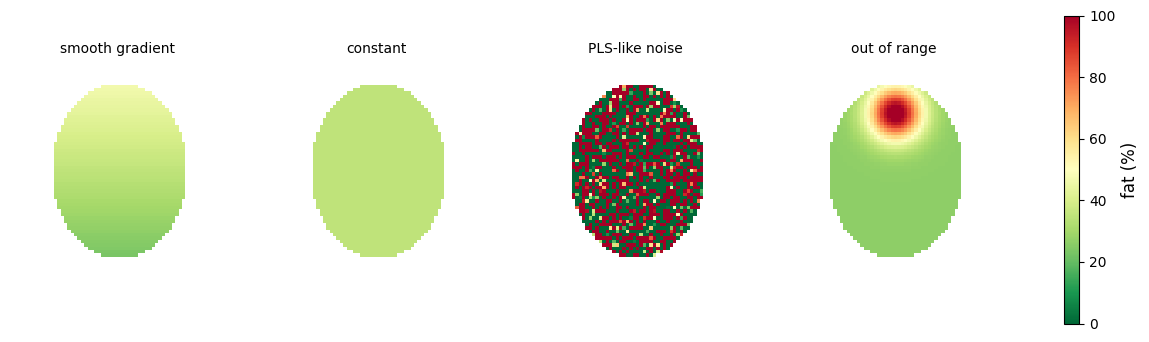

,MSE,Out of Bounds,Smoothness,Total,mean inside mask
smooth gradient,0.0,0.0000,4.394500e+00,4.394500e+00,35.0
constant,0.0,0.0000,0.000000e+00,0.000000e+00,35.0
PLS-like noise,0.0,121434.4844,7.598610e+06,7.720045e+06,35.0
out of range,0.0,0.2162,2.261331e+02,2.263493e+02,35.0


In [44]:
H = W = 64
yy, xx = np.mgrid[0:H, 0:W]
toy_mask = (((yy - 32) / 26) ** 2 + ((xx - 32) / 20) ** 2 < 1).astype(np.float32)
rng = np.random.default_rng(1)
ref = 35.0

def recentre(mp):
    ## shift a map so that its mean inside the mask is exactly the reference
    return mp - mp[toy_mask > 0].mean() + ref

toy_maps = {
    'smooth gradient': recentre(35 + 15 * (32 - yy) / 32),
    'constant': np.full((H, W), ref),
    'PLS-like noise': recentre(ref + rng.normal(0, 300, (H, W))),
    'out of range': recentre(35 + 80 * np.exp(-((yy - 15) ** 2 + (xx - 32) ** 2) / 60)),
}

rows = {}
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (name, mp) in zip(axes, toy_maps.items()):
    y_pred = torch.tensor(mp, dtype=torch.float32)[None, None]
    terms = loss_terms(None, torch.from_numpy(toy_mask)[None, None], torch.tensor([[ref]]), y_pred)
    rows[name] = {k: float(v) for k, v in weighted_losses(terms, terms['n']).items()}
    rows[name]['mean inside mask'] = float(terms['mean_pred'])
    im = ax.imshow(np.where(toy_mask > 0, mp, np.nan), cmap='RdYlGn_r', vmin=0, vmax=100)
    ax.set_title(name)
    ax.axis('off')
fig.colorbar(im, ax=axes, label='fat (%)')
plt.show()
display(pd.DataFrame(rows).T.drop(columns='L2 Regularization').round(4))

Things to notice:

- All four maps have a perfect mean, so the MSE is zero for all of them. The MSE alone cannot tell a meaningful map from noise.
- The PLS-like map is punished enormously by both the smoothness and the out-of-bounds terms.
- The constant map has the lowest loss of all. So why does the U-Net not simply predict a constant per slice? Because a single U-Net must work for all slices at once, and it only gets the correct mean for every belly by actually reading the spectra pixel by pixel. Spatial structure is what remains when the network explains the means with real chemical information and the smoothness term removes the noise. The smoothness loss does not create structure, it only suppresses speckle.

### 5.7) A link to geostatistics: smoothness loss and the nugget effect

In section 8 we will measure how much of a map's variance is spatially correlated, using the semivariogram from geostatistics:
$$\gamma(\delta_h, \delta_w) = \frac{1}{2}\,\frac{\sum_{h,w} M_{h,w}\big(\hat{Y}_{h,w} - \hat{Y}_{h+\delta_h, w+\delta_w}\big)^2}{\sum_{h,w} M_{h,w}}, \qquad C_0 = \frac{\gamma(0, 1) + \gamma(1, 0)}{2}.$$
$C_0$, the nugget effect, is the variance between direct neighbours: variance without spatial correlation. Compare its formula with the smoothness loss: with an eroded mask they are the same sum, and $C_0 = \mathrm{SL}/4$. In other words, the U-Net is trained to directly minimise the nugget effect, which PLS never does. Let us verify the identity numerically on the toy maps.

In [45]:
def semivariogram(Y, M, dh, dw):
    H, W = Y.shape
    Mi = M[:H - dh, :W - dw]
    diff = Y[:H - dh, :W - dw] - Y[dh:, dw:]
    return 0.5 * np.sum(Mi * diff ** 2) / np.sum(Mi)


def nugget(Y, M):
    return 0.5 * (semivariogram(Y, M, 0, 1) + semivariogram(Y, M, 1, 0))


for name, mp in toy_maps.items():
    terms = loss_terms(None, torch.from_numpy(toy_mask)[None, None], torch.tensor([[ref]]),
                       torch.tensor(mp, dtype=torch.float32)[None, None])
    print(f'{name:16s}  C0 = {nugget(mp, toy_mask):12.4f}   SL / 4 = {float(terms["smooth"]) / 4:12.4f}')

smooth gradient   C0 =       0.0549   SL / 4 =       0.0549
constant          C0 =       0.0000   SL / 4 =       0.0000
PLS-like noise    C0 =   94982.6294   SL / 4 =   94982.6328
out of range      C0 =       2.8267   SL / 4 =       2.8267


## 6) The training pipeline

### 6.1) The recipe of the study

- Optimizer: Adam with initial learning rate $10^{-3}$, $\beta_1 = 0.9$, $\beta_2 = 0.999$. Note that the L2 regularisation is part of the loss here, unlike the AdamW weight decay of the previous notebook.
- Batch size 1, as in the original U-Net, because a full slice already fills the GPU memory. One optimizer step per slice.
- After each epoch, the model with the final weights of that epoch is evaluated on the whole training set and the whole validation set, so that training and validation numbers are directly comparable (the paper discusses why the usual running average over training batches would not be).
- Model selection on the validation MSE (not on the total loss): the main interest is an accurate mean, the other terms only shape the solution.
- Burn-in of 30 epochs without any scheduling. After that: if the validation MSE did not improve for 10 epochs, restore the best weights and optimizer state and divide the learning rate by 10 (minimum $10^{-7}$). If it did not improve for 30 epochs, stop. At most 250 epochs.
- Random horizontal and vertical flips of the training slices.

The weight restoring is important with batch size 1: gradients are noisy, and returning to a known good state before taking smaller steps damps the oscillations.

### 6.2) The training function

The function below implements this recipe. It also logs every loss term separately for the training and validation sets.

In [46]:
def evaluate(model, loader, device):
    '''Weighted loss terms over a whole loader, normalised by the number of images.'''
    model.eval()
    acc = {'oob': 0.0, 'smooth': 0.0, 'sse': 0.0, 'n': 0}
    with torch.no_grad():
        for img, (mask, target), _ in loader:
            img, mask, target = img.to(device), mask.to(device), target.to(device)
            t = loss_terms(model, mask, target, model(img))
            for k in ['oob', 'smooth', 'sse']:
                acc[k] += float(t[k])
            acc['n'] += t['n']
        acc['l2'] = float(l2_of_weights(model))
    return {k: float(v) for k, v in weighted_losses(acc, acc['n']).items()}


def train_unet(model, train_loader, val_loader, train_eval_loader, save_dir, init_lr=1e-3, max_epochs=250,
               burn_in_epochs=30, reduce_lr_patience=10, early_stop_patience=30, lr_multiplier=0.1, min_lr=1e-7,
               device=DEVICE, eval_train=True):
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)
    best_path, optim_path = save_dir / 'best_weights.pt', save_dir / 'best_weights_optim_state.pt'
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=init_lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=reduce_lr_patience - 1,
                                                           factor=lr_multiplier, min_lr=min_lr)
    ## Average batch size of an epoch: len(dataset) / number of batches (1.0 for batch size 1)
    avg_batch_size = len(train_loader.dataset) / len(train_loader)

    def save_checkpoint():
        torch.save(model.state_dict(), best_path)
        torch.save(optimizer.state_dict(), optim_path)

    def restore_checkpoint():
        ## Restore the best weights and optimizer state, but keep the current (reduced) learning rate
        current_lr = optimizer.param_groups[0]['lr']
        model.load_state_dict(torch.load(best_path, map_location=device, weights_only=True))
        optimizer.load_state_dict(torch.load(optim_path, map_location=device, weights_only=True))
        optimizer.param_groups[0]['lr'] = current_lr

    history = []
    best_val, best_burn_in, early_best, early_counter, best_epoch = float('inf'), float('inf'), float('inf'), 0, None
    save_checkpoint()

    for epoch in range(1, max_epochs + 1):
        t0 = time.time()
        model.train()
        for img, (mask, target), _ in tqdm(train_loader, desc=f'epoch {epoch}', leave=False):
            img, mask, target = img.to(device), mask.to(device), target.to(device)
            optimizer.zero_grad()
            y_pred = model(img)
            loss = weighted_losses(loss_terms(model, mask, target, y_pred), avg_batch_size)['Total']
            loss.backward()
            optimizer.step()

        train_m = evaluate(model, train_eval_loader, device) if eval_train else {}
        val_m = evaluate(model, val_loader, device)
        cur_lr = optimizer.param_groups[0]['lr']
        history.append({'epoch': epoch, 'lr': cur_lr, **{f'train {k}': v for k, v in train_m.items()},
                        **{f'val {k}': v for k, v in val_m.items()}})
        decision = val_m['MSE']                          # model selection on the validation MSE
        if epoch <= burn_in_epochs:
            best_burn_in = min(best_burn_in, decision)
        if decision < best_val:
            best_val, best_epoch = decision, epoch
            save_checkpoint()
        print(f"epoch {epoch:3d} | train total {train_m.get('Total', float('nan')):9.3f} | val MSE {decision:9.3f} "
              f"| val smooth {val_m['Smoothness']:7.3f} | val OOB {val_m['Out of Bounds']:9.4f} | lr {cur_lr:.0e} | {time.time() - t0:.0f}s")

        if epoch == burn_in_epochs:
            print('Burn-in epochs completed.')
            early_best = min(early_best, best_burn_in)
            scheduler.step(best_burn_in)
        if epoch > burn_in_epochs:
            if decision < early_best:
                early_best, early_counter = decision, 0
            else:
                early_counter += 1
            if early_counter >= early_stop_patience:
                print(f'Early stopping at epoch {epoch}')
                break
            scheduler.step(decision)
            if optimizer.param_groups[0]['lr'] < cur_lr:
                print(f"Learning rate reduced to {optimizer.param_groups[0]['lr']:.0e}. Restoring best weights.")
                restore_checkpoint()

    print(f'Finished. Best epoch {best_epoch} with validation MSE {best_val:.3f}. Weights: {best_path}')
    model.load_state_dict(torch.load(best_path, map_location=device, weights_only=True))
    history = pd.DataFrame(history)
    history.to_csv(save_dir / 'logs.csv', index=False)
    return history, best_epoch


def plot_loss_terms(history, best_epoch):
    '''The equivalent of Figure 5 of the paper: every weighted loss term for train and validation.'''
    names = ['Total', 'MSE', 'Smoothness', 'Out of Bounds', 'L2 Regularization']
    fig, axes = plt.subplots(1, len(names), figsize=(4 * len(names), 3.3))
    for ax, n in zip(axes, names):
        for split, color in [('train', 'gray'), ('val', 'tab:blue')]:
            col = f'{split} {n}'
            if col in history:
                ax.plot(history.epoch, history[col], color=color, label=split)
        if best_epoch:
            ax.axvline(best_epoch, color='k', ls='--', lw=1)
        ax.set_title(n)
        ax.set_xlabel('epoch')
        if (history.filter(like=n) > 0).all().all():
            ax.set_yscale('log')
    axes[0].legend()
    plt.tight_layout()
    plt.show()

### 6.3) How the five U-Nets of the study were trained

Training loops over the five CV folds. For fold $k$ we build a fresh model, creates the four loaders and calls the training function, with the full schedule of the study:

```python
for val_split in [1, 2, 3, 4, 5]:
    train_sets = [s for s in [1, 2, 3, 4, 5] if s != val_split]
    train_loader = DataLoader(PreprocessedImageDataset(UNET_DATA, train_sets, transform=get_random_flip_transform()),
                              batch_size=1, shuffle=True, num_workers=4)
    train_eval_loader = DataLoader(PreprocessedImageDataset(UNET_DATA, train_sets), batch_size=1)
    val_loader = DataLoader(PreprocessedImageDataset(UNET_DATA, [val_split]), batch_size=1)
    history, best_epoch = train_unet(build_model(), train_loader, val_loader, train_eval_loader,
                                     save_dir=Path('runs') / f'{val_split}', init_lr=1e-3, max_epochs=250,
                                     burn_in_epochs=30, reduce_lr_patience=10, early_stop_patience=30)
    plot_loss_terms(history, best_epoch)
```

Each fold reads about 200 GB of images per epoch, which is why the five resulting networks are loaded from file in section 7 instead.

### 6.4) A demonstration of the training step

What we can do here is watch the training step itself at work. Two tricks keep the demonstration fast:

1. A fully convolutional network does not care about the absolute image size, as long as the size is valid (section 4.4). We therefore cut a piece of 856 x 632 pixels from the centre of a slice. With valid convolutions the border lost is the same for any input size (92 output pixels on every side), so the matching piece of the mask is easy to find: an input crop starting at row $r_0$ produces output pixels that start at row $r_0/2$ of the full output map.
2. We take a fresh, untrained compound model and run a few Adam steps on these crops, cycling through the slices of the lean example belly, with random flips switched on.

For every step we print the four weighted loss terms. Watch the out-of-bounds term: a randomly initialised network has no idea that fat lies between 0 and 100, so this term starts large and collapses within a few steps, exactly the behaviour reported in the paper. And watch the MSE: one belly has one reference value, so the network quickly learns to hit its mean. That is memorisation, not learning, and the example bellies belong to the test set, so the demonstration model is thrown away afterwards.

Demonstration on belly 10 (5 slices), crops of 856 x 632 pixels
step  1 | 10-1 | mean in mask     0.38 (ref 25.5) | MSE 630 | Out of Bounds 0 | Smoothness 0.131 | L2 Regularization 13.7 | Total 644 | 1.4 s
step  2 | 10-2 | mean in mask  4455.63 (ref 25.5) | MSE 1.96e+07 | Out of Bounds 6.11e+08 | Smoothness 29.9 | L2 Regularization 13.1 | Total 6.31e+08 | 0.7 s
step  3 | 10-3 | mean in mask     1.44 (ref 25.5) | MSE 578 | Out of Bounds 0 | Smoothness 0.109 | L2 Regularization 12.7 | Total 591 | 0.7 s
step  4 | 10-4 | mean in mask     1.04 (ref 25.5) | MSE 597 | Out of Bounds 0 | Smoothness 0.0828 | L2 Regularization 12.3 | Total 610 | 0.5 s
step  5 | 10-5 | mean in mask     6.73 (ref 25.5) | MSE 352 | Out of Bounds 0 | Smoothness 0.0571 | L2 Regularization 11.9 | Total 364 | 0.7 s
step  6 | 10-1 | mean in mask   119.11 (ref 25.5) | MSE 8.77e+03 | Out of Bounds 1.19e+04 | Smoothness 0.12 | L2 Regularization 11.6 | Total 2.07e+04 | 0.6 s
step  7 | 10-2 | mean in mask     5.63 (ref 25.5) 

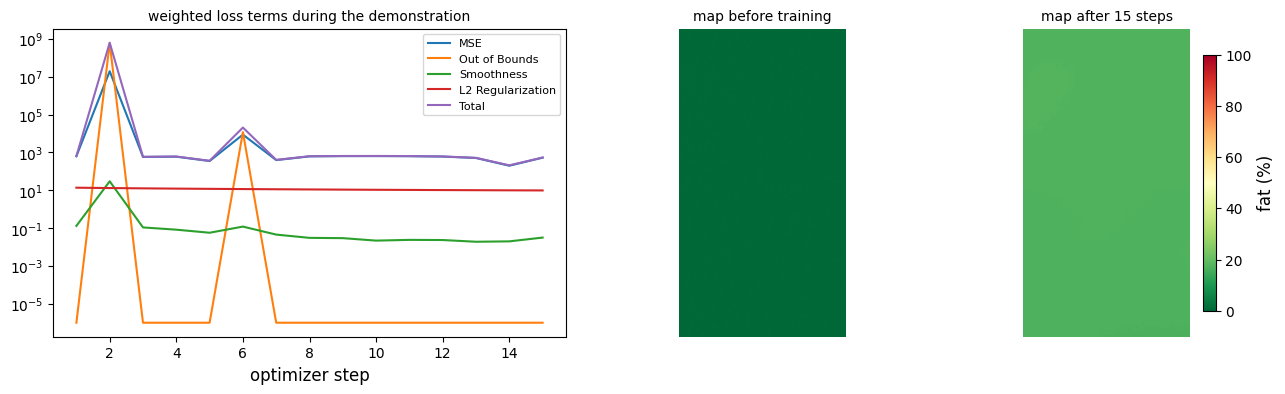

In [47]:
def centre_crop_pair(img, mask, unet_hw):
    '''Crop a valid-size piece from the centre of a padded slice, and the matching piece of the mask.'''
    in_h, in_w = 2 * unet_hw[0], 2 * unet_hw[1]                      # input size before the stride-2 front-end
    out_h, out_w = unet_size_table(in_h)[-1][1], unet_size_table(in_w)[-1][1]
    r0 = ((img.shape[-2] - in_h) // 2) // 2 * 2                         # even offsets keep the grids aligned
    c0 = ((img.shape[-1] - in_w) // 2) // 2 * 2
    return img[..., r0:r0 + in_h, c0:c0 + in_w], mask[..., r0 // 2:r0 // 2 + out_h, c0 // 2:c0 // 2 + out_w]


def show_maps(model, img, mask):
    model.eval()
    with torch.no_grad():
        pred = model(img[None].to(DEVICE)).cpu().numpy()[0, 0]
    m = mask.numpy()[0]
    return pred, np.where(m > 0, pred, np.nan)


EXAMPLE_BELLIES = sorted(slices.meat_id.unique())
lean_id = min(EXAMPLE_BELLIES, key=lambda m: float(meta.loc[meta.meat_id == m, 'Fat_chem'].iloc[0]))
demo_ds = PreprocessedImageDataset(UNET_DATA, TEST_SETS + CV_SETS, transform=get_random_flip_transform(),
                                   stems=sorted(slices.loc[slices.meat_id == lean_id, 'stem']))
print(f'Demonstration on belly {lean_id} ({len(demo_ds)} slices), crops of {2 * DEMO_UNET_HW[0]} x {2 * DEMO_UNET_HW[1]} pixels')

reproducible_comp()
demo_model = build_model().to(DEVICE)
optimizer = torch.optim.Adam(demo_model.parameters(), lr=1e-3)
img0, (mask0, ref0), _ = PreprocessedImageDataset(UNET_DATA, TEST_SETS + CV_SETS, stems=demo_ds.stems)[0]
img0, mask0 = centre_crop_pair(img0, mask0, DEMO_UNET_HW)
_, before = show_maps(demo_model, img0, mask0)

log = []
for step in range(1, DEMO_STEPS + 1):
    t0 = time.time()
    img, (mask, ref), stem = demo_ds[(step - 1) % len(demo_ds)]
    img, mask = centre_crop_pair(img, mask, DEMO_UNET_HW)
    img, mask, ref = img[None].to(DEVICE), mask[None].to(DEVICE), ref[None].to(DEVICE)
    demo_model.train()
    optimizer.zero_grad()
    y_pred = demo_model(img)                                        # (1, 1, h, w) chemical map
    terms = weighted_losses(loss_terms(demo_model, mask, ref, y_pred), 1.0)
    terms['Total'].backward()                                       # gradients of the total loss (eq. 7)
    optimizer.step()
    log.append({k: float(v.detach()) if torch.is_tensor(v) else float(v) for k, v in terms.items()})
    print(f"step {step:2d} | {stem} | mean in mask {((y_pred * mask).sum() / mask.sum()).item():8.2f} (ref {ref.item():.1f}) | "
          + ' | '.join(f'{k} {v:.3g}' for k, v in log[-1].items()) + f' | {time.time() - t0:.1f} s')

_, after = show_maps(demo_model, img0, mask0)
log = pd.DataFrame(log, index=range(1, DEMO_STEPS + 1))
fig, axes = plt.subplots(1, 3, figsize=(15, 4), gridspec_kw={'width_ratios': [2, 1, 1]})
for col in log.columns:
    axes[0].plot(log.index, log[col].clip(lower=1e-6), label=col)
axes[0].set_yscale('log')
axes[0].set_xlabel('optimizer step')
axes[0].set_title('weighted loss terms during the demonstration')
axes[0].legend(fontsize=8)
for ax, mp, title in [(axes[1], before, 'map before training'), (axes[2], after, f'map after {DEMO_STEPS} steps')]:
    im = ax.imshow(mp, cmap='RdYlGn_r', vmin=0, vmax=100)
    ax.set_title(title)
    ax.axis('off')
fig.colorbar(im, ax=axes[2], fraction=0.05, label='fat (%)')
plt.show()

del demo_model, optimizer
if DEVICE == 'cuda':
    torch.cuda.empty_cache()

## 7) GPU CHECKPOINT: load the trained U-Net ensemble

This is the interruption point. Everything below runs on a CPU as well. If you start here on a fresh CPU runtime, run sections 0 to 5 first.

We load the five U-Nets that were trained on the full CV set, one per fold, from the course folder. The files load directly into `build_model()`, because the model in this notebook is exactly the architecture the authors trained.

`map_location` moves the stored tensors to whatever device we have, so the same files work on a GPU and on a CPU. On a CPU only the first `EVAL_MEMBERS_CPU` members are used to save time.

In [48]:
def weight_files():
    local = [PRETRAINED_DIR / f'{i}' / 'best_weights.pt' for i in range(1, 6)]
    return local


def load_member(path):
    m = build_model()
    try:
        state = torch.load(path, map_location=DEVICE, weights_only=True)
    except Exception as e:
        print(f'Could not read {path}')
        raise e
    missing, unexpected = m.load_state_dict(state, strict=False)
    if missing or unexpected:
        print(f'WARNING {path}: {len(missing)} missing and {len(unexpected)} unexpected keys')
    return m.to(DEVICE).eval()


n_members = EVAL_MEMBERS_GPU if DEVICE == 'cuda' else EVAL_MEMBERS_CPU
files = weight_files()[:n_members]
members = [load_member(f) for f in files]
ensemble = EnsembleModel(*members).eval()
print(f'Ensemble of {len(members)} U-Net(s) loaded from:')
for f in files:
    print('  ', f)

Ensemble of 5 U-Net(s) loaded from:
   data/end2end/unet/1/best_weights.pt
   data/end2end/unet/2/best_weights.pt
   data/end2end/unet/3/best_weights.pt
   data/end2end/unet/4/best_weights.pt
   data/end2end/unet/5/best_weights.pt


## 8) Chemical maps

### 8.1) Predicting test slices

We now predict the slices of the two example bellies. Both belong to the test set, which was never used for training or model selection of the five U-Nets. For every slice we keep the full predicted map, the mask and the reference. On a CPU this is the slow part of the notebook: by default only two slices per belly and two ensemble members are used there (see section 0).

In [49]:
eval_ids = EXAMPLE_BELLIES
per_belly = EVAL_SLICES_PER_BELLY_GPU if DEVICE == 'cuda' else EVAL_SLICES_PER_BELLY_CPU
eval_stems = []
for meat_id in eval_ids:
    stems = sorted(slices.loc[slices.meat_id == meat_id, 'stem'], key=lambda s: int(s.split('-')[1]))
    eval_stems += stems[:per_belly] if per_belly else stems
eval_ds = PreprocessedImageDataset(UNET_DATA, TEST_SETS + CV_SETS, stems=eval_stems)
print(f'Predicting {len(eval_ds)} slices of {len(eval_ids)} bellies with {len(members)} member(s) on {DEVICE}')

predictions = {}
t0 = time.time()
with torch.no_grad():
    for img, (mask, ref), stem in tqdm(DataLoader(eval_ds, batch_size=1, num_workers=0), desc='slices'):
        pred = ensemble(img.to(DEVICE)).cpu().numpy()[0, 0]          # (OUT_H, OUT_W) chemical map
        predictions[stem[0]] = {'map': pred, 'mask': mask.numpy()[0, 0], 'ref': float(ref)}
print(f'done in {time.time() - t0:.0f} s')

Predicting 10 slices of 2 bellies with 5 member(s) on cuda


slices: 100%|██████████| 10/10 [00:13<00:00,  1.39s/it]

done in 14 s


The figure below reproduces Figure 7 of the paper for one slice: the input, the masked chemical map and the histogram of pixel predictions.

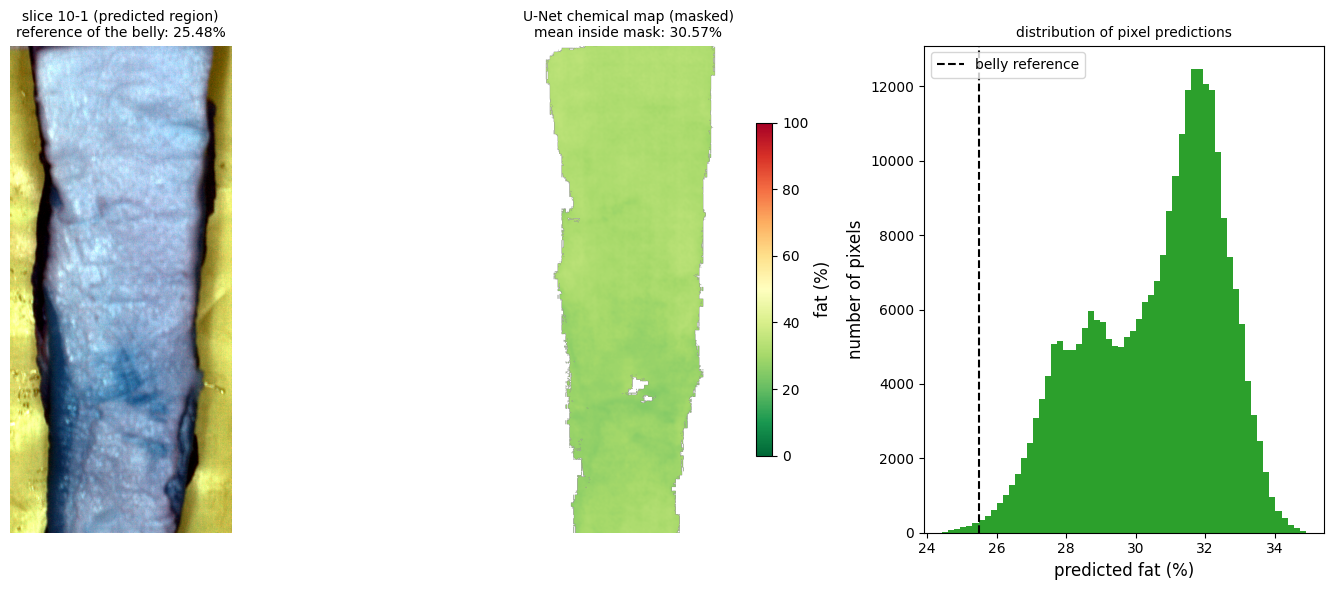

In [50]:
stem = sorted(predictions)[0]
p = predictions[stem]
img_np, _ = load_slice(stem)
crop = false_colour(img_np[:, top:top + reg_h, left:left + reg_w])[::2, ::2]
inside = p['map'][p['mask'] > 0]

fig, axes = plt.subplots(1, 3, figsize=(14, 6), gridspec_kw={'width_ratios': [1, 1, 1.2]})
axes[0].imshow(crop)
axes[0].set_title(f'slice {stem} (predicted region)\nreference of the belly: {p["ref"]:.2f}%')
im = axes[1].imshow(np.where(p['mask'] > 0, p['map'], np.nan), cmap='RdYlGn_r', vmin=0, vmax=100)
axes[1].set_title(f'U-Net chemical map (masked)\nmean inside mask: {inside.mean():.2f}%')
fig.colorbar(im, ax=axes[1], fraction=0.05, label='fat (%)')
for a in axes[:2]:
    a.axis('off')
axes[2].hist(inside, bins=60, color='tab:green')
axes[2].axvline(p['ref'], color='k', ls='--', label='belly reference')
axes[2].set_xlabel('predicted fat (%)')
axes[2].set_ylabel('number of pixels')
axes[2].set_title('distribution of pixel predictions')
axes[2].legend()
plt.tight_layout()
plt.show()

Now all slices of the predicted bellies, ordered by slice number (as in Figure 8 of the paper, slice 1 is the cranial end). Look for structure: in the reference paper reports that the dorsal (upper) and cranial parts have more fat than the ventral (lower) and caudal parts, a pattern the network was never told about.

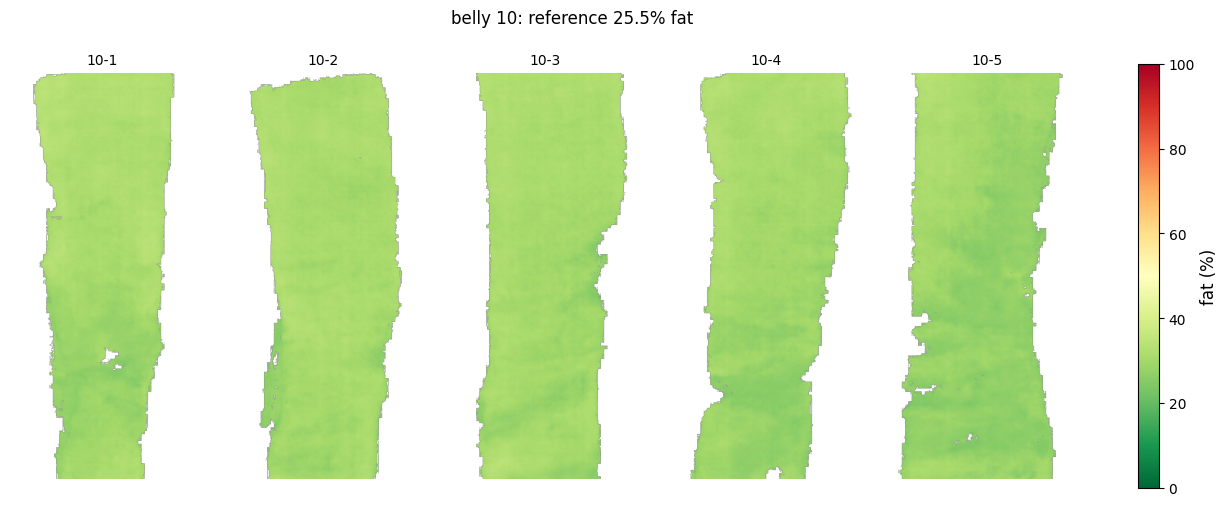

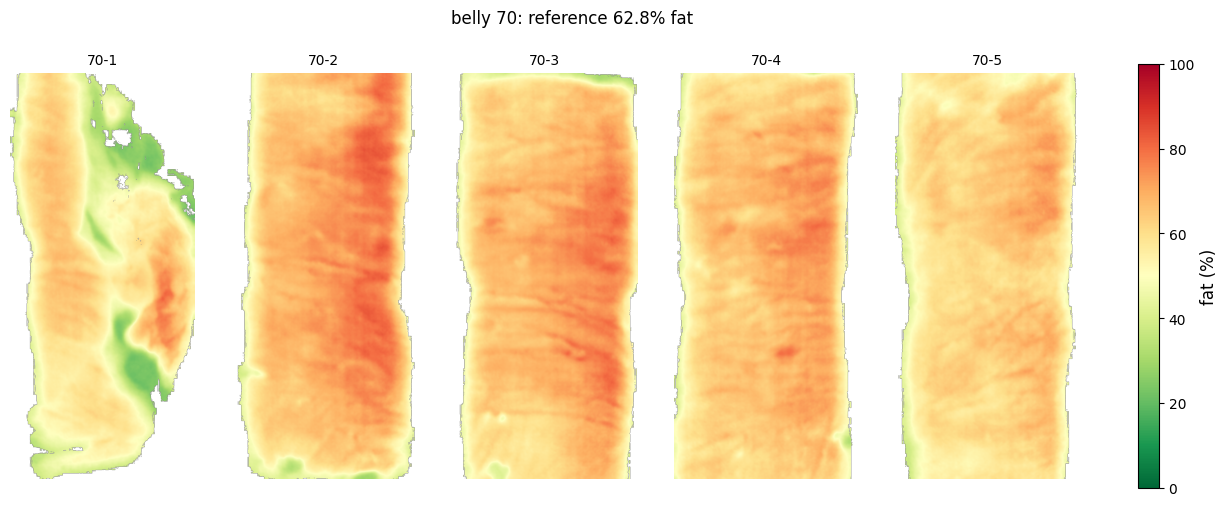

In [51]:
for meat_id in eval_ids:
    stems = sorted([s for s in predictions if int(s.split('-')[0]) == meat_id], key=lambda s: int(s.split('-')[1]))
    fig, axes = plt.subplots(1, len(stems), figsize=(3 * len(stems), 5.5), squeeze=False)
    for ax, s in zip(axes[0], stems):
        q = predictions[s]
        im = ax.imshow(np.where(q['mask'] > 0, q['map'], np.nan), cmap='RdYlGn_r', vmin=0, vmax=100)
        ax.set_title(s)
        ax.axis('off')
    fig.suptitle(f'belly {meat_id}: reference {predictions[stems[0]]["ref"]:.1f}% fat')
    fig.colorbar(im, ax=axes[0].tolist(), fraction=0.03, label='fat (%)')
    plt.show()

### 8.2) From maps to belly predictions

To compare with the reference, the paper averages the pixel predictions over all pixels inside the masks of all slices of a belly (so larger slices weigh more, as in a mean spectrum).

In [52]:
rows = []
for meat_id in eval_ids:
    ps = [v for s, v in predictions.items() if int(s.split('-')[0]) == meat_id]
    pix = np.concatenate([v['map'][v['mask'] > 0] for v in ps])
    rows.append({'meat_id': meat_id, 'reference': ps[0]['ref'], 'U-Net prediction': pix.mean(),
                 'pixels below 0 %': int((pix < 0).sum()), 'pixels above 100 %': int((pix > 100).sum())})
belly = pd.DataFrame(rows)
belly['error'] = belly['U-Net prediction'] - belly['reference']
display(belly.round(2))

,meat_id,reference,U-Net prediction,pixels below 0 %,pixels above 100 %,error
0,10,25.48,29.85,0,0,4.37
1,70,62.78,62.25,0,0,-0.53


Two bellies are too few to compute a meaningful RMSE. For reference, the paper reports a test RMSE of 5.25% for the U-Net ensemble on all 60 test bellies, against 5.64% for PLS. If only some slices were predicted (on a CPU), the belly value above is the mean over those slices only.

### 8.3) How spatially structured are the maps?

Let's compare the total variance $\sigma^2$ of a map inside its mask with the nugget effect $C_0$ (section 5.7). The ratio $C_0/\sigma^2$ is the fraction of variance that is spatially uncorrelated, and $1 - C_0/\sigma^2$ the fraction that is spatially correlated. The paper reports, averaged over the test set, $1 - C_0/\sigma^2 = 0.999$ for the U-Net and only $0.02$ for PLS.

In [53]:
spatial = []
for s, v in predictions.items():
    var = float(np.var(v['map'][v['mask'] > 0]))
    c0 = nugget(v['map'], v['mask'])
    spatial.append({'slice': s, 'variance': var, 'C0': c0, 'C0 / variance': c0 / var, '1 - C0 / variance': 1 - c0 / var})
spatial = pd.DataFrame(spatial)
display(spatial.round(4))
print('mean over the predicted slices:')
display(spatial.drop(columns='slice').mean().round(4).to_frame('U-Net').T)

,slice,variance,C0,C0 / variance,1 - C0 / variance
0,10-1,3.6469,0.0069,0.0019,0.9981
1,10-2,1.5672,0.0070,0.0045,0.9955
2,10-3,1.8415,0.0071,0.0039,0.9961
3,10-4,3.2624,0.0068,0.0021,0.9979
4,10-5,3.3384,0.0068,0.0020,0.9980
5,70-1,139.1197,0.0512,0.0004,0.9996
6,70-2,80.3012,0.0388,0.0005,0.9995
7,70-3,63.4035,0.0370,0.0006,0.9994
8,70-4,45.3960,0.0336,0.0007,0.9993
9,70-5,38.0125,0.0263,0.0007,0.9993


mean over the predicted slices:


,variance,C0,C0 / variance,1 - C0 / variance
U-Net,37.9889,0.0222,0.0017,0.9983


## 9) For contrast: the classical pixel-wise PLS map

To see what the U-Net improves on, we recreate the classical approach in a simplified form:

1. Calibrate PLS on belly mean spectra of the CV set (splits 1 to 5), preprocessed with SNV and a Savitzky-Golay second derivative (window 7, order 2), with the number of components chosen by 5-fold cross-validation over the CV splits.
2. Apply the same preprocessing and the same PLS model to every single pixel of a test slice.

Simplifications compared with the paper: the paper preprocessed every pixel before averaging; we use the stored mean absorbance spectra, binned to the 62 bands of the images, and preprocess the mean. Since SNV is not linear, this is not identical, but the qualitative picture is the same. 

PLS components chosen by cross-validation: 18 (CV RMSE 5.48 % fat)


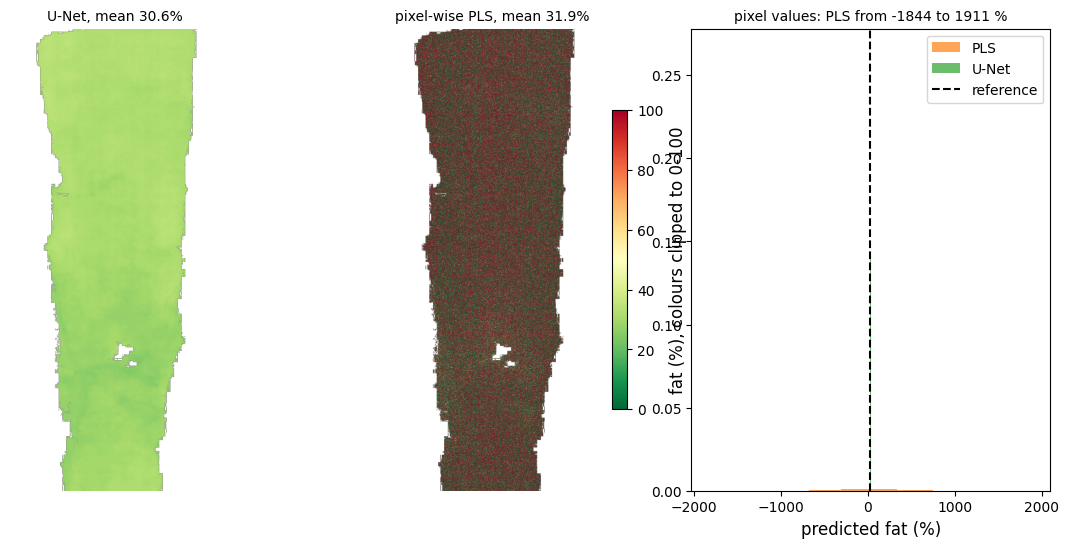

,variance,C0,pixels outside 0-100 %,1 - C0 / variance
U-Net,3.6469,0.0069,0.0000,0.9981
PLS,114978.5207,112548.3434,0.8776,0.0211


In [54]:
from ikpls.numpy import PLS


def snv(X):
    X = np.asarray(X, dtype=np.float64)
    return (X - X.mean(axis=-1, keepdims=True)) / X.std(axis=-1, keepdims=True)


def preprocess(X):
    return savgol_filter(snv(X), window_length=7, polyorder=2, deriv=2, axis=-1)


cv = meta[meta.split.isin(CV_SETS)]
X_cv = np.stack([np.load(SPECTRA_PATH / f'{m}.npy')[-124:].reshape(62, 2).mean(axis=1) for m in cv.meat_id])
Xp_cv, y_cv, folds = preprocess(X_cv), cv[REFERENCE_VALUES].to_numpy(float), cv.split.to_numpy()

## 5-fold cross-validation over the CV splits to choose the number of components
A_MAX = 20
cv_sse = np.zeros(A_MAX)
for f in CV_SETS:
    pls_f = PLS(algorithm=1, center_X=True, center_Y=True, scale_X=False, scale_Y=False)
    pls_f.fit(Xp_cv[folds != f], y_cv[folds != f], A=A_MAX)
    cv_sse += np.sum((pls_f.predict(Xp_cv[folds == f]) - y_cv[folds == f][None]) ** 2, axis=(1, 2))
best_a = int(np.argmin(cv_sse)) + 1
pls = PLS(algorithm=1, center_X=True, center_Y=True, scale_X=False, scale_Y=False)
pls.fit(Xp_cv, y_cv, A=A_MAX)
print(f'PLS components chosen by cross-validation: {best_a} (CV RMSE {np.sqrt(cv_sse[best_a - 1] / len(y_cv)):.2f} % fat)')


## Free the large arrays of the earlier sections: this cell needs a few GB of RAM of its own
for name in ['img', 'x', 'img0', 'q']:
    globals().pop(name, None)
gc.collect()


def pls_map(stem, rows_per_block=128):
    '''Pixel-wise PLS prediction on the predicted region of a slice, at full resolution.
    The slice is read block by block (memory mapping), so only a small part is in memory at once.'''
    q = np.load(UNET_DATA / 'images' / f'{stem}.npy', mmap_mode='r')
    bias = float(np.load(UNET_DATA / 'quant_biases' / f'{stem}.npy'))
    scale = float(np.load(UNET_DATA / 'quant_scales' / f'{stem}.npy'))
    out = []
    for r0 in range(0, reg_h, rows_per_block):
        block = np.asarray(q[:, top + r0:top + min(r0 + rows_per_block, reg_h), left:left + reg_w], dtype=np.float32)
        block = block / scale + bias                                             # dequantise
        h = block.shape[1]
        absorb = -np.log10(np.clip(block.reshape(62, -1).T, 1e-6, None))         # (pixels, 62)
        out.append(pls.predict(preprocess(absorb), n_components=best_a).reshape(h, reg_w))
    return np.concatenate(out)


stem = sorted(predictions)[0]
p = predictions[stem]
pmap = pls_map(stem)
pmask = np.kron(p['mask'], np.ones((2, 2)))           # the mask at full resolution
u_in, p_in = p['map'][p['mask'] > 0], pmap[pmask > 0]

fig, axes = plt.subplots(1, 3, figsize=(14, 6), gridspec_kw={'width_ratios': [1, 1, 1.2]})
im = axes[0].imshow(np.where(p['mask'] > 0, p['map'], np.nan), cmap='RdYlGn_r', vmin=0, vmax=100)
axes[0].set_title(f'U-Net, mean {u_in.mean():.1f}%')
axes[1].imshow(np.where(pmask > 0, pmap, np.nan), cmap='RdYlGn_r', vmin=0, vmax=100)
axes[1].set_title(f'pixel-wise PLS, mean {p_in.mean():.1f}%')
fig.colorbar(im, ax=axes[1], fraction=0.05, label='fat (%), colours clipped to 0-100')
for a in axes[:2]:
    a.axis('off')
axes[2].hist(p_in, bins=100, color='tab:orange', alpha=0.7, density=True, label='PLS')
axes[2].hist(u_in, bins=60, color='tab:green', alpha=0.7, density=True, label='U-Net')
axes[2].axvline(p['ref'], color='k', ls='--', label='reference')
axes[2].set_xlabel('predicted fat (%)')
axes[2].legend()
axes[2].set_title(f'pixel values: PLS from {p_in.min():.0f} to {p_in.max():.0f} %')
plt.show()

summary = pd.DataFrame({
    'U-Net': {'variance': np.var(u_in), 'C0': nugget(p['map'], p['mask']), 'pixels outside 0-100 %': np.mean((u_in < 0) | (u_in > 100))},
    'PLS': {'variance': np.var(p_in), 'C0': nugget(pmap, pmask), 'pixels outside 0-100 %': np.mean((p_in < 0) | (p_in > 100))},
}).T
summary['1 - C0 / variance'] = 1 - summary['C0'] / summary['variance']
display(summary.round(4))

The PLS map has a roughly correct mean, which is why PLS works well on mean spectra, but almost all of its pixel variance is noise between neighbours, and a large part of the pixels fall outside the physically possible range. The U-Net map has a fraction of the variance, nearly all of it spatially structured.

Would simply smoothing the PLS map fix this? The paper tried: the PLS maps had to be smoothed so strongly to reach a low $C_0$ that all fine detail disappeared. Try it yourself with `scipy.ndimage.gaussian_filter` on `pmap`.